# NETFLIX DATA OBSERVATION

Business Problem

Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries

Start by exploring a few questions: 
1. What type of content is available in different countries?
2. How has the number of movies released per year changed over the last 20-30 years?
3. Comparison of tv shows vs. movies.
4. What is the best time to launch a TV show?
5. Analysis of actors/directors of different types of shows/movies.
6. Does Netflix has more focus on TV Shows than movies in recent years
7. Understanding what content is available in different countries

My findings:
1. Top 10 countries where most number of movies/shows are released.
2. Count of movies and shows which are being released only in united states.
3. Number of releases in top 10 countries with respect to type.
4. How many movies and shows are released in top 10 countries using barplot.
5. Top 10 movie directors in last 30 years.
6. Top 10 TV Show director in last 30 years.
7. Directors who are in top10 movie director and also in top 10 TV show directors.
8. How top 10 show director are performing in top 10 countries with most releases.
9. How top 10 movie director are performing in top 10 countries with most releases.






In [ ]:
# imported all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Loaded the dataset
data = pd.read_csv('netflix.txt')
data.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [ ]:
# Checking about type of columns present
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
# Checking for duplicated show_id
data[data['show_id'].duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [9]:
# Checking for duplicated shows
data[data['title'].duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [11]:
# 1. What type of content is available in different countries?
data['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [ ]:
# Top 10 countries where most number of movies/shows are released
data['country'].value_counts()[:10]

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [56]:
# Does netflix has more focus on which type.
data['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x163e4841e50>,
 [Text(-0.6357552923508217, 0.8976721050851036, 'Movie'),
  Text(0.6357555848494867, -0.8976718979296876, 'TV Show')],
 [Text(-0.3467756140095391, 0.48963933004642013, '69.62'),
  Text(0.3467757735542654, -0.4896392170525568, '30.38')])

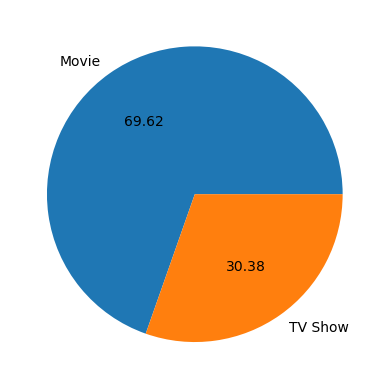

In [62]:
plt.pie(data['type'].value_counts().values, labels=data['type'].value_counts().index, autopct='%.2f')

# From the pie chart we can conclude the netflix has more focus on movies.

In [ ]:
# count of movies and shows which are being released only in united states.
us_data = data[data['country'] == 'United States']
us_data.shape
us_data.groupby('type')['title'].count().val

type
Movie      2058
TV Show     760
Name: title, dtype: int64

([<matplotlib.patches.Wedge at 0x163dd31e5d0>,
 [Text(-0.7282339268672178, 0.8244242522873474, 'Movie'),
  Text(0.7282338023826107, -0.8244243622476017, 'TV Show')],
 [Text(-0.3972185055639369, 0.4496859557930985, '73.0%'),
  Text(0.39721843766324216, -0.4496860157714191, '27.0%')])

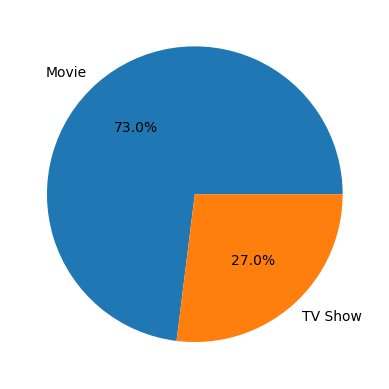

In [ ]:
# We can use piechart to see the proportion
values = us_data.groupby('type')['title'].count().values
labels = us_data['type'].unique()
plt.pie(values, labels=labels, autopct='%1.1f%%')
# So we conclude more number of moives are released in US than TV Shows

In [32]:
# Filtering top 10 countries where there are most releases
top_countries = data['country'].value_counts()[:10].index
top_countries_data = data[data['country'].isin(top_countries)]
top_countries_data.shape

(5319, 12)

In [50]:
# Number of releases in top 10 countries with repect to type
releases_wrt_type = top_countries_data.groupby(['country','type'])['title'].count().reset_index()

Text(0, 0.5, 'Country')

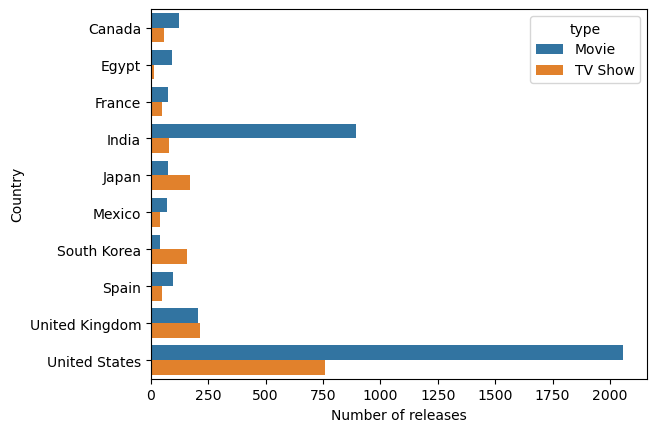

In [ ]:
# How many movies and shows are released in top 10 countries using barplot.
sns.barplot(data=releases_wrt_type, y=releases_wrt_type['country'], x=releases_wrt_type['title'], hue='type')
plt.xticks(rotation=0)
plt.xlabel('Number of releases')
plt.ylabel('Country')

# Netflix has more focus on release of movies in US and India.
# Netflix has more focus on release of TV Shows in Japan, South Korea and UK.

In [52]:
top_countries_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
15,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...


In [128]:
data['release_year'] = data['release_year'].astype('int')

In [132]:
data['type'].value_counts()
data.drop('added_year', inplace=True, axis=1)

In [153]:
# How has the number of movies released per year changed over the last 20-30 years?
movies_data_last_30_years = data[(data['type'] == 'Movie') & (data['release_year'] >= 1990) & (data['release_year'] <= 2020)]
shows_data_last_30_years = data[(data['type'] == 'TV Show') & (data['release_year'] >= 1990) & (data['release_year'] <= 2020)]

labels = ['1990-2000','2000-2010','2010-2020']
bins = [1990,2000,2010,2020]

movies_data_last_30_years['release_bins'] = pd.cut(movies_data_last_30_years['release_year'], labels=labels, bins=bins)
shows_data_last_30_years['release_bins'] = pd.cut(shows_data_last_30_years['release_year'], labels=labels, bins=bins)

movies_data_last_30_years['release_bins'].value_counts().values
# shows_data_last_30_years['release_bins'].value_counts()


C:\Users\subha\AppData\Local\Temp\ipykernel_26380\2228389742.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_data_last_30_years['release_bins'] = pd.cut(movies_data_last_30_years['release_year'], labels=labels, bins=bins)
C:\Users\subha\AppData\Local\Temp\ipykernel_26380\2228389742.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shows_data_last_30_years['release_bins'] = pd.cut(shows_data_last_30_years['release_year'], labels=labels, bins=bins)


array([4547,  798,  255])

-----------> CategoricalIndex(['1990-2000', '2000-2010', '2010-2020'], categories=['1990-2000', '2000-2010', '2010-2020'], ordered=True, dtype='category', name='release_bins') [ 255  798 4547]


Text(0, 0.5, 'Movies Count')

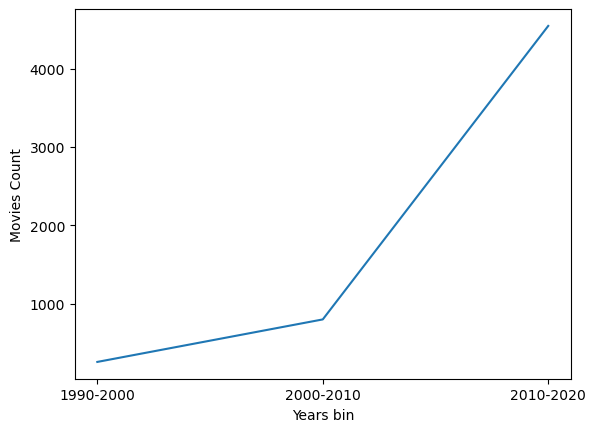

In [ ]:
x = movies_data_last_30_years['release_bins'].value_counts().sort_index().index
y = movies_data_last_30_years['release_bins'].value_counts().sort_index().values
print('----------->',x, y)
plt.plot(x,y)
plt.xlabel('Years bin')
plt.ylabel('Movies Count')

# From here we can see that in the last 30 years the netflix releases in movies has increased in each decaded

-----------> CategoricalIndex(['1990-2000', '2000-2010', '2010-2020'], categories=['1990-2000', '2000-2010', '2010-2020'], ordered=True, dtype='category', name='release_bins') [  34  169 2139]


Text(0, 0.5, 'Movies Count')

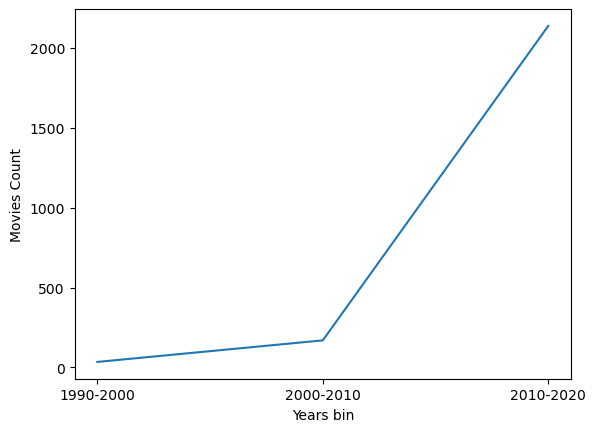

In [ ]:
# # How has the number of TV show released per year changed over the last 20-30 years?
x = shows_data_last_30_years['release_bins'].value_counts().sort_index().index
y = shows_data_last_30_years['release_bins'].value_counts().sort_index().values
print('----------->',x, y)
plt.plot(x,y)
plt.xlabel('Years bin')
plt.ylabel('Movies Count')

# From here we can see that in the last 30 years the netflix releases in TV show has also increased in each decaded

Text(0, 0.5, 'Movies Count')

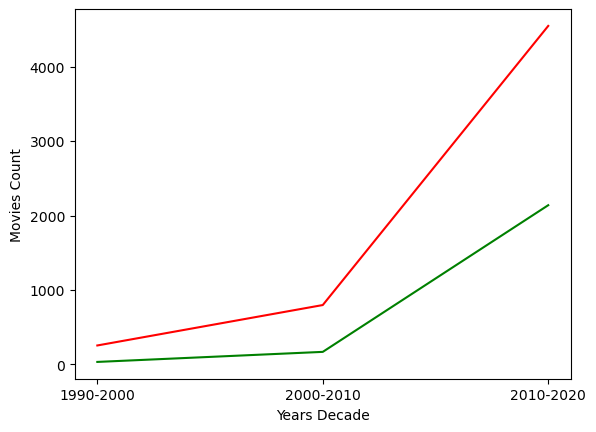

In [ ]:
# Now If we compare the releases in movies and TV show in last 30 years

mx = movies_data_last_30_years['release_bins'].value_counts().sort_index().index
my = movies_data_last_30_years['release_bins'].value_counts().sort_index().values
sx = shows_data_last_30_years['release_bins'].value_counts().sort_index().index
sy = shows_data_last_30_years['release_bins'].value_counts().sort_index().values

plt.plot(mx,my, color='red')
plt.plot(sx,sy, color='green')

plt.xlabel('Years Decade')
plt.ylabel('Movies Count')

# So we conclude both are increasing but netflix has more focus on movies rather than shows.
# In the recent years netflix has more focus on movies

In [171]:
# Top 10 movie directors in last 30 years
movies_data_last_30_years['director'].value_counts().sort_values(ascending=False)[:10]

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              15
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Don Michael Paul          10
David Dhawan               9
Kunle Afolayan             8
Name: count, dtype: int64

In [172]:
# Top 10 TV Show directors in last 30 years
shows_data_last_30_years['director'].value_counts().sort_values(ascending=False)[:10]

director
Alastair Fothergill                                                                   3
Rob Seidenglanz                                                                       2
Shin Won-ho                                                                           2
Stan Lathan                                                                           2
Iginio Straffi                                                                        2
Ken Burns                                                                             2
Uzodinma Okpechi                                                                      1
Hsu Fu-chun                                                                           1
Sidharta Tata, Aco Tenriyagelli, Dian Sastrowardoyo, Ifa Isfansyah, Jason Iskandar    1
Shen Leping                                                                           1
Name: count, dtype: int64

In [ ]:
# Directors who are in top10 movie director and also in top 10 TV show directors
np.intersect1d(shows_data_last_30_years['director'].value_counts().sort_values(ascending=False)[:10].index, movies_data_last_30_years['director'].value_counts().sort_values(ascending=False)[:10].index)

# No directors were found

array([], dtype=object)

In [ ]:
# How top 10 movie director are performing in top 10 countries with most releases.
md = movies_data_last_30_years['director'].value_counts().sort_values(ascending=False)[:10].index
top_m_director_in_top_countries = top_countries_data[top_countries_data['director'].isin(md)]
top_m_director_in_top_countries.groupby(['country','director'])['title'].count()

# From here are concluding that Director like David Dhawan ,Rajiv Chilaka, Suhas Kadav are more popular in India for movies likewise rest

country        director              
India          David Dhawan               9
               Rajiv Chilaka              3
               Suhas Kadav                1
Mexico         Raúl Campos, Jan Suter     9
United States  Don Michael Paul           5
               Jay Chapman               12
               Jay Karas                 14
               Marcus Raboy              15
Name: title, dtype: int64

Text(0.5, 0, 'Movies Count')

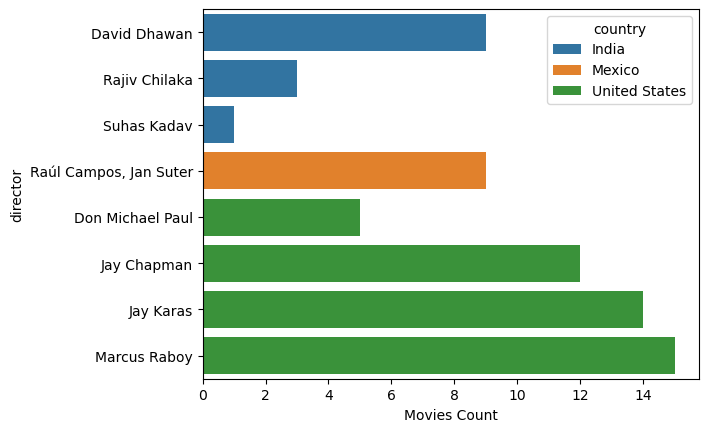

In [189]:
a = top_m_director_in_top_countries.groupby(['country','director'])['title'].count().reset_index()

sns.barplot(data=a, y='director', x='title', hue='country')
plt.xlabel('Movies Count')

In [ ]:
# How top 10 show director are performing in top 10 countries with most releases.
sd = shows_data_last_30_years['director'].value_counts().sort_values(ascending=False)[:10].index
top_s_director_in_top_countries = top_countries_data[top_countries_data['director'].isin(sd)]
top_s_director_in_top_countries.groupby(['country','director'])['title'].count()

# Directors like Shin Won-ho are more popular in SK for TV Shows and likewise

country         director           
South Korea     Shin Won-ho            2
United Kingdom  Alastair Fothergill    2
United States   Ken Burns              2
                Rob Seidenglanz        2
                Stan Lathan            4
Name: title, dtype: int64

Text(0.5, 0, 'TV Show Count')

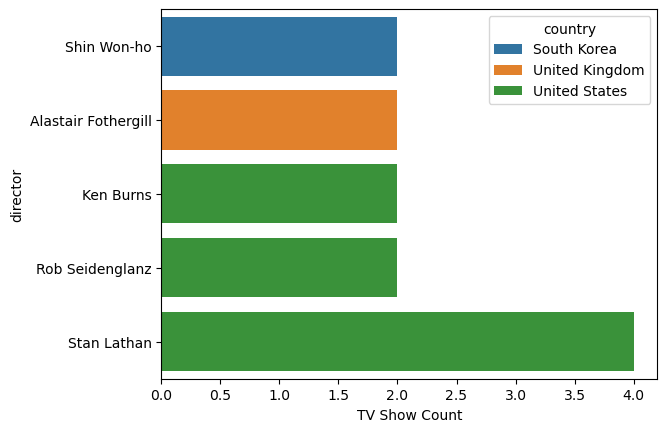

In [190]:
b = top_s_director_in_top_countries.groupby(['country','director'])['title'].count().reset_index()

sns.barplot(data=b, y='director', x='title', hue='country')
plt.xlabel('TV Show Count')